# **Matplotlib Dashboard & Visualization**

**Tables:** KPI Summary, Monthly Trend, Category Performance, State Performance, Segment Summary, CLV Table
**Charts:**

* Line → Monthly Revenue
* Bar → Category Revenue & Profit
* Map → State Revenue
* Pie → Segment Distribution
* Pareto Curve → Revenue concentration
* Heatmap → Cohort Retention

**Business Impact:**

* Fast, **data-driven decisions**
* Margin control & retention improvement
* Risk detection & operational optimization
* **Investor-ready presentation**
---

In [2]:
import os

# Check what CSV files exist in your project
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

./state_performance_summary.csv
./category_performance_summary.csv
./df.csv
./segment_summary.csv
./monthly_performance_summary.csv
./.ipynb_checkpoints/state_performance_summary-checkpoint.csv
./.ipynb_checkpoints/category_performance_summary-checkpoint.csv


In [4]:
import pandas as pd

df                           = pd.read_csv('./df.csv')
monthly_performance_summary  = pd.read_csv('./monthly_performance_summary.csv')
category_performance_summary = pd.read_csv('./category_performance_summary.csv')
state_performance_summary    = pd.read_csv('./state_performance_summary.csv')
segment_summary              = pd.read_csv('./segment_summary.csv')

print("✅ All loaded!")

✅ All loaded!


In [6]:
datasets = {
    'df'                          : df,
    'monthly_performance_summary' : monthly_performance_summary,
    'category_performance_summary': category_performance_summary,
    'state_performance_summary'   : state_performance_summary,
    'segment_summary'             : segment_summary,
}

for name, data in datasets.items():
    print(f"\n✅ {name}: {data.shape}")
    print(data.columns.tolist())


✅ df: (115030, 33)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

✅ monthly_performance_summary: (23, 11)
['purchase_month', 'total_revenue', 'total_profit', 'total_orders', 'total_customers', 'profit_margin_%', 'AOV', 'MoM_growth_%', 'Revenue_3M_MA', 'MoM_growth_3M_avg_%', 'YoY_growth_%']

✅ category_performance_summary: (74, 7)
['product_category_name', 

In [7]:
for name, data in datasets.items():
    print(f"\n📋 {name}:")
    print(data.columns.tolist())
    print(data.head(2))


📋 df:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      20

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# ✅ A. PERFORMANCE ANALYSIS .

### 1️⃣ Monthly Revenue Trend (Mandatory)

* Line chart
* Revenue
* Add Profit line
* Add MoM Growth %

✔ Detect growth
✔ Detect seasonality
✔ Detect revenue drops

---

In [10]:


# Convert purchase_month to datetime so x axis sorts properly
monthly_performance_summary['purchase_month'] = pd.to_datetime(
    monthly_performance_summary['purchase_month']
)

# Remove rows where revenue is 0 (empty months like 2016-11)
monthly_clean = monthly_performance_summary[
    monthly_performance_summary['total_revenue'] > 0
].copy()

print(monthly_clean[['purchase_month', 'total_revenue', 'total_profit']].head())

  purchase_month  total_revenue  total_profit
0     2016-10-01       48133.30      14789.48
2     2016-12-01          19.62         10.90
3     2017-01-01      136634.49      40604.42
4     2017-02-01      283420.83      87946.99
5     2017-03-01      440064.65     135020.18


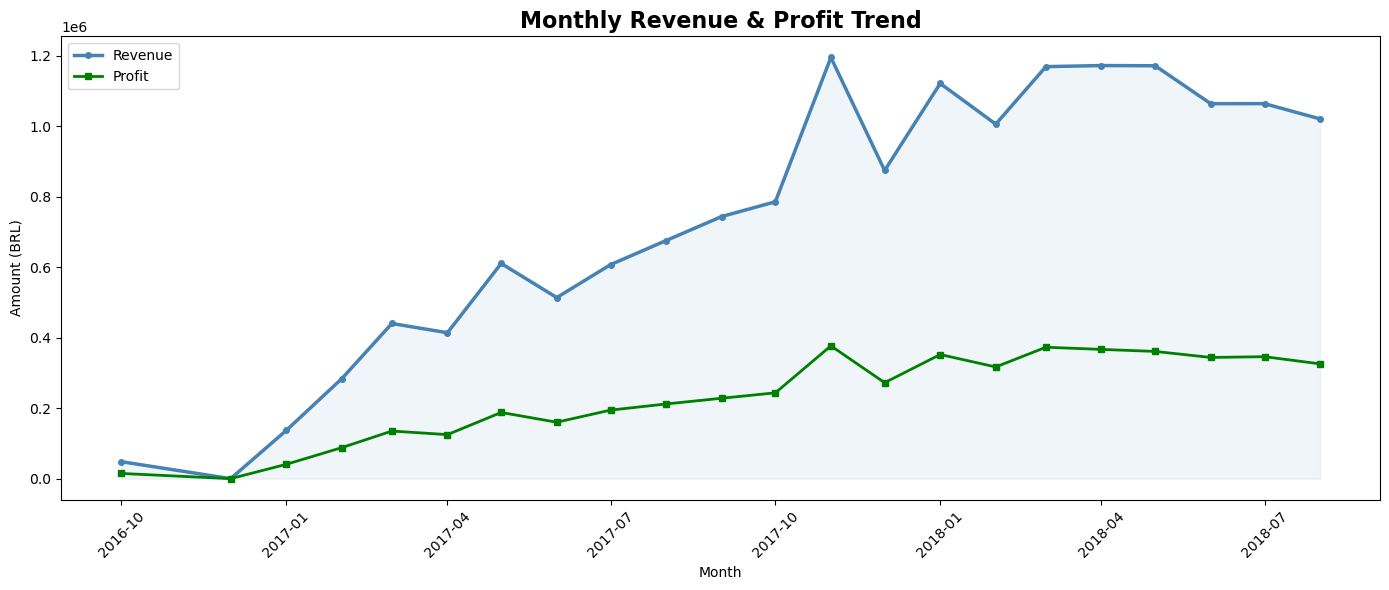

In [14]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Revenue Line ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_revenue'],
         color='steelblue', linewidth=2.5,
         marker='o', markersize=4, label='Revenue')

# --- Profit Line ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_profit'],
         color='green', linewidth=2,
         marker='s', markersize=4, label='Profit')

# --- Fill under Revenue ---
ax1.fill_between(monthly_clean['purchase_month'],
                 monthly_clean['total_revenue'],
                 alpha=0.08, color='steelblue')

# --- Labels ---
ax1.set_title('Monthly Revenue & Profit Trend', fontsize=16, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Amount (BRL)')
ax1.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2️⃣ Monthly Orders Trend

* Line chart
* Total orders per month

✔ Demand growth
✔ Customer activity

---

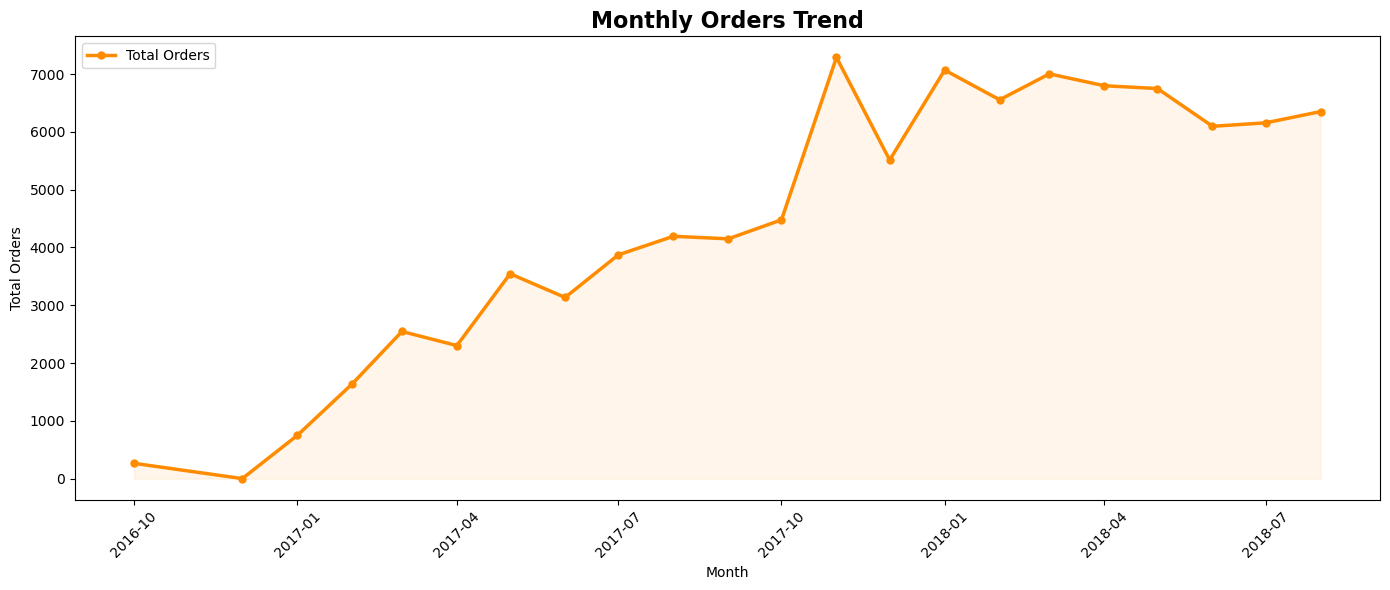

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_clean['purchase_month'],
        monthly_clean['total_orders'],
        color='darkorange', linewidth=2.5,
        marker='o', markersize=5,
        label='Total Orders')

ax.fill_between(monthly_clean['purchase_month'],
                monthly_clean['total_orders'],
                alpha=0.08, color='darkorange')

ax.set_title('Monthly Orders Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Orders')
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3️⃣ Monthly AOV Trend

* Revenue / Orders

✔ Are customers spending more?.                            
✔ Pricing improvement?.                                 

--------

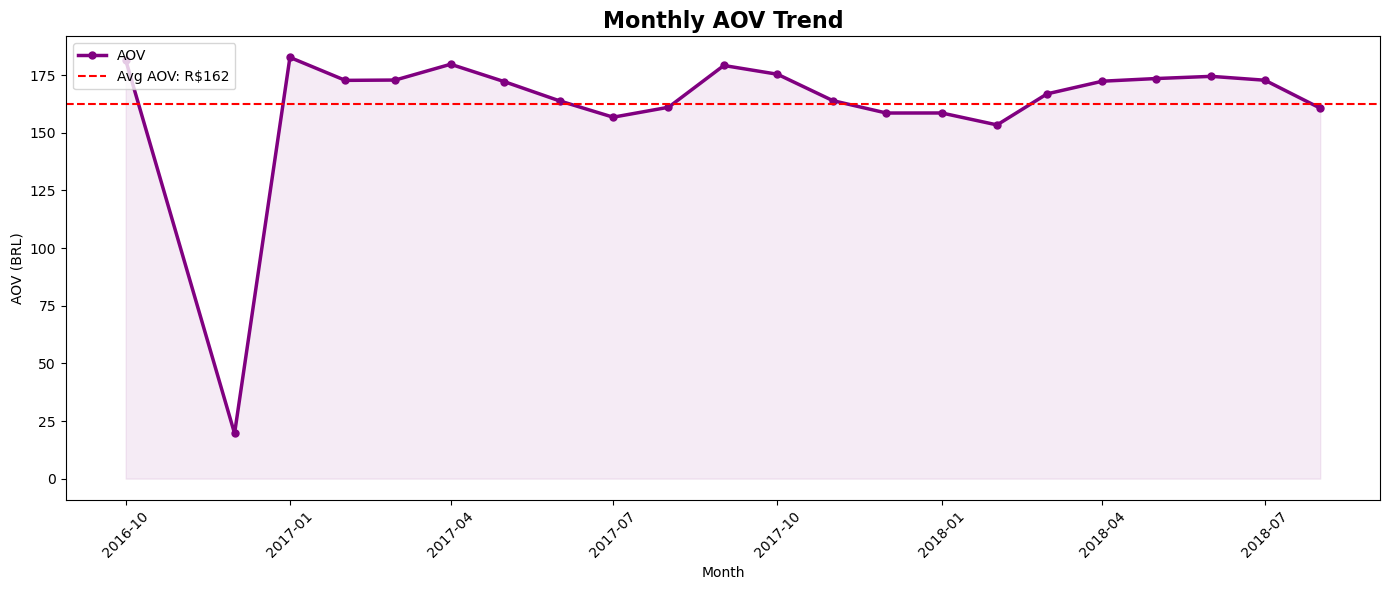

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_clean['purchase_month'],
        monthly_clean['AOV'],
        color='purple', linewidth=2.5,
        marker='o', markersize=5,
        label='AOV')

ax.fill_between(monthly_clean['purchase_month'],
                monthly_clean['AOV'],
                alpha=0.08, color='purple')

# Add horizontal average line
avg_aov = monthly_clean['AOV'].mean()
ax.axhline(y=avg_aov, color='red', linewidth=1.5,
           linestyle='--', label=f'Avg AOV: R${avg_aov:.0f}')

ax.set_title('Monthly AOV Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('AOV (BRL)')
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4️⃣ Monthly Profit Trend

✔ Margin stability.                                     
✔ Cost pressure months.                             

------

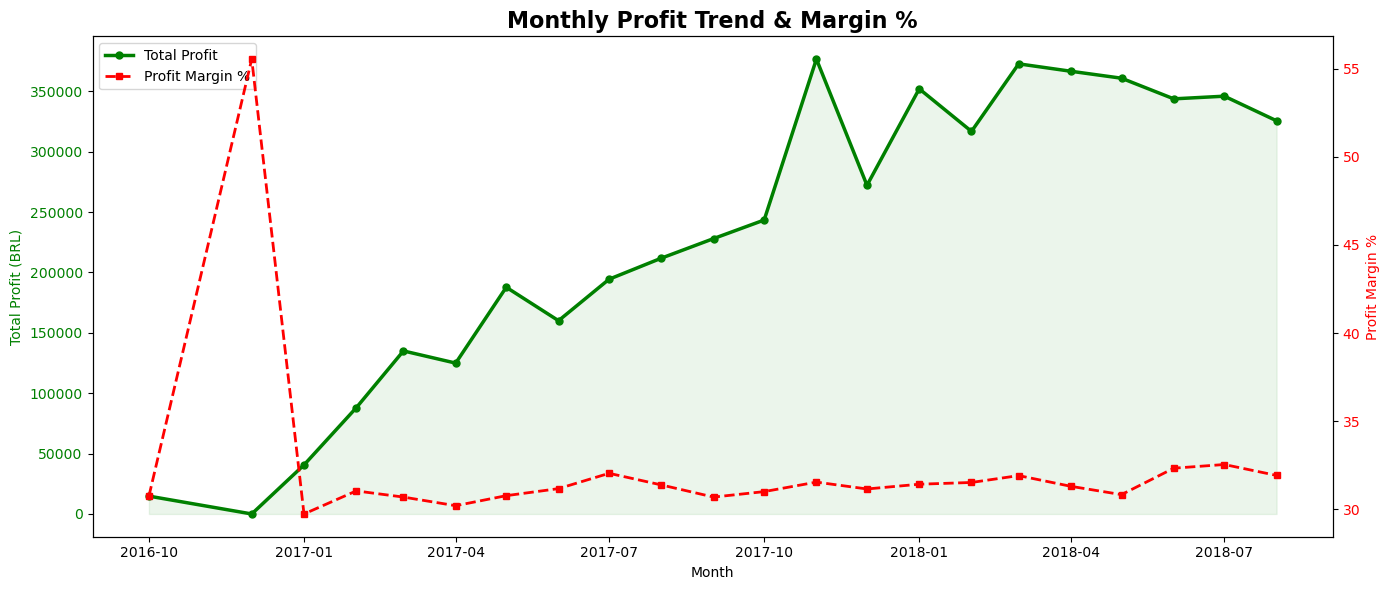

In [16]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Left Y axis — Profit ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_profit'],
         color='green', linewidth=2.5,
         marker='o', markersize=5,
         label='Total Profit')

ax1.fill_between(monthly_clean['purchase_month'],
                 monthly_clean['total_profit'],
                 alpha=0.08, color='green')

ax1.set_ylabel('Total Profit (BRL)', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# --- Right Y axis — Margin % ---
ax2 = ax1.twinx()

ax2.plot(monthly_clean['purchase_month'],
         monthly_clean['profit_margin_%'],
         color='red', linewidth=2,
         marker='s', markersize=4,
         linestyle='--', label='Profit Margin %')

ax2.set_ylabel('Profit Margin %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Labels ---
ax1.set_title('Monthly Profit Trend & Margin %',
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Month')

# --- Combined Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 5️⃣ Revenue vs Profit Margin Trend

Dual axis line chart

✔ If revenue ↑ but margin ↓ → cost issue.                        

---------

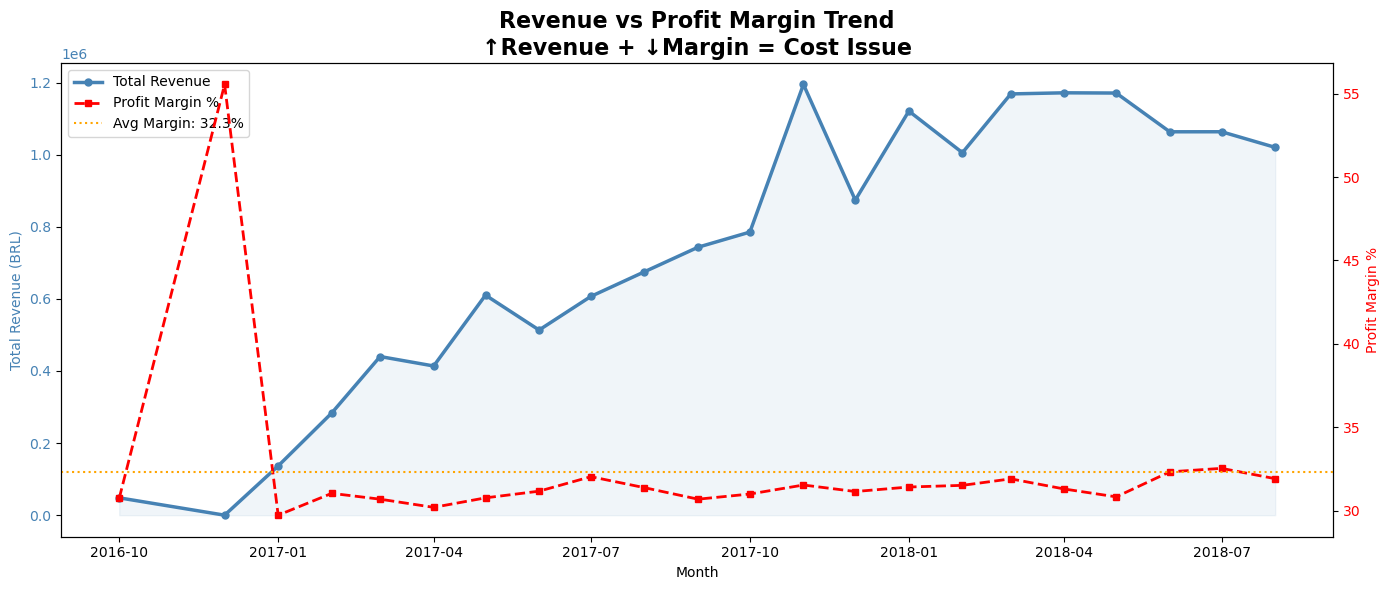

In [17]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Left Y Axis — Revenue ---
ax1.plot(monthly_clean['purchase_month'],
         monthly_clean['total_revenue'],
         color='steelblue', linewidth=2.5,
         marker='o', markersize=5,
         label='Total Revenue')

ax1.fill_between(monthly_clean['purchase_month'],
                 monthly_clean['total_revenue'],
                 alpha=0.08, color='steelblue')

ax1.set_ylabel('Total Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# --- Right Y Axis — Margin % ---
ax2 = ax1.twinx()

ax2.plot(monthly_clean['purchase_month'],
         monthly_clean['profit_margin_%'],
         color='red', linewidth=2,
         marker='s', markersize=4,
         linestyle='--',
         label='Profit Margin %')

# --- Danger Zone --- 
avg_margin = monthly_clean['profit_margin_%'].mean()
ax2.axhline(y=avg_margin, color='orange',
            linewidth=1.5, linestyle=':',
            label=f'Avg Margin: {avg_margin:.1f}%')

ax2.set_ylabel('Profit Margin %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- Labels ---
ax1.set_title('Revenue vs Profit Margin Trend\n↑Revenue + ↓Margin = Cost Issue',
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Month')

# --- Combined Legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ✅ B. PRODUCT PERFORMANCE

### 6️⃣ Top 10 Categories by Revenue

Horizontal bar chart.                  

------------

### 7️⃣ Top 10 Categories by Profit

Bar chart

------

### 8️⃣ Category Profit Margin %

Bar chart

✔ Margin leakage detection

------



### 9️⃣ Category Scatter Plot (VERY IMPORTANT)

X = Revenue
Y = Profit Margin

This is strategic visual:

* High revenue + Low margin → leakage
* Low revenue + High margin → scale opportunity

This chart alone shows business thinking.

-----------



### 🔟 Loss-Making Orders by Category

Bar chart

✔ Pricing or cost issue

-------

### 1️⃣1️⃣ Freight Ratio Impact

Scatter:
X = Revenue.                     
Y = Freight / Revenue.                      

✔ Logistics pressure detection

---

# ✅ C. REGIONAL PERFORMANCE



### 1️⃣2️⃣ Revenue by State

Bar chart

------------

### 1️⃣3️⃣ Profit Margin by State

Bar chart

✔ Inefficient regions

--------

### 1️⃣4️⃣ Orders by State

✔ Demand density.            

----------

# ✅ D. CUSTOMER INTELLIGENCE (RFM + CLV)



### 1️⃣5️⃣ RFM Segment Distribution

Bar chart

✔ Customer quality mix

---

### 1️⃣6️⃣ Revenue by Segment

✔ Who drives money

---------

### 1️⃣7️⃣ Profit by Segment

✔ High revenue but low profit?

-----------


### 1️⃣8️⃣ CLV Distribution (Histogram)

✔ Few high-value customers?

---------------

### 1️⃣9️⃣ Top 10 Customers by CLV

✔ Dependency risk

-------

# ✅ E. RETENTION & CHURN

### 2️⃣0️⃣ Churn Distribution (Donut)

✔ 58.9% churn

------

### 2️⃣1️⃣ Recency Distribution (Histogram)

✔ How long customers stay inactive

--------

### 2️⃣2️⃣ Cohort Retention Heatmap

✔ Month 1 drop?
✔ Long-term loyalty?

This makes project advanced level.

-------

# ✅ F. PARETO ANALYSIS


### 2️⃣3️⃣ Cumulative Revenue Curve

* Sorted customers
* 80% line

✔ Revenue concentration
✔ Dependency analysis

---